<div class="alert alert-block alert-success" style="font-size:20px;">
    NEURAL NETWORK FROM SCRATCH: MASTERCLASS
</div>

<div class="alert alert-block alert-danger">

LOADING THE DATASET

https://www.kaggle.com/datasets/hojjatk/mnist-dataset/data</div>

In [1]:
import numpy as np
import nnfs
nnfs.init()

<div class="alert alert-block alert-danger">

PLOTTING THE DATASET</div>

In [2]:
import gzip
import numpy as np

# Function to load images
def load_images(filename):
    with open(filename, 'rb') as f:   # ✅ use open instead of gzip
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28 * 28)

# Function to load labels
def load_labels(filename):
    with open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data


# Load training data
X_train = load_images('/home/sudhir/Desktop/NNFS/MNIST/train-images-idx3-ubyte/train-images-idx3-ubyte')
y_train = load_labels('/home/sudhir/Desktop/NNFS/MNIST/train-labels-idx1-ubyte/train-labels-idx1-ubyte')

# Load test data
X_test = load_images('/home/sudhir/Desktop/NNFS/MNIST/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
y_test = load_labels('/home/sudhir/Desktop/NNFS/MNIST/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

# Normalize (VERY IMPORTANT)
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


# # 🚀 Optional (Better Training)
# # You can speed up training by using a subset:
# X = X_train[:5000]
# y = y_train[:5000]

(60000, 784) (60000,)
(10000, 784) (10000,)


<div class="alert alert-block alert-danger">

CREATING LAYERS: FORWARD AND BACKWARD PASS</div>

In [3]:
# Dense layer
class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from input ones, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases

    # Backward pass
    def backward(self, dvalues):
        # Gradients on parameters
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        # Gradient on values
        self.dinputs = np.dot(dvalues, self.weights.T)


<div class="alert alert-block alert-danger">

RELU ACTIVATION: FORWARD AND BACKWARD PASS</div>

In [4]:
# ReLU activation
class Activation_ReLU:
    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from inputs
        self.output = np.maximum(0, inputs)

    # Backward pass
    def backward(self, dvalues):
        # Since we need to modify the original variable,
        # let’s make a copy of values first
        self.dinputs = dvalues.copy()
        # Zero gradient where input values were negative
        self.dinputs[self.inputs <= 0] = 0

<div class="alert alert-block alert-danger">

SOFTMAX ACTIVATION: FORWARD PASS</div>

In [5]:
# Softmax activation
class Activation_Softmax:
 # Forward pass
 def forward(self, inputs):
 # Get unnormalized probabilities
  exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
 # Normalize them for each sample
  probabilities = exp_values / np.sum(exp_values, axis=1,keepdims=True)
  self.output = probabilities

<div class="alert alert-block alert-danger">
LOSS CLASS </div>

In [6]:
# Common loss class
class Loss:
 # Calculates the data and regularization losses
 # given model output and ground truth values
 def calculate(self, output, y):
  # Calculate sample losses
  sample_losses = self.forward(output, y)
  # Calculate mean loss
  data_loss = np.mean(sample_losses)
  # Return loss
  return data_loss

<div class="alert alert-block alert-danger">

CATEGORICAL CROSS ENTROPY LOSS: FORWARD AND BACKWARD PASS</div>

In [7]:
class Loss_CategoricalCrossentropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Number of samples in a batch
        samples = len(y_pred)

        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values -
        # only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values - only for one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )

        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

    # Backward pass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        # Number of labels in every sample
        # We'll use the first sample to count them
        labels = len(dvalues[0])

        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]

        # Calculate gradient
        self.dinputs = -y_true / dvalues
        # Normalize gradient
        self.dinputs = self.dinputs / samples

<div class="alert alert-block alert-danger">

COMBINED SOFTMAX ACTIVATION AND CATEGORICAL CROSS ENTROPY FOR LAST LAYER: FORWARD AND BACKWARD PASS</div>

In [8]:
# Softmax classifier - combined Softmax activation
# and cross-entropy loss for faster backward step
class Activation_Softmax_Loss_CategoricalCrossentropy:
    # Creates activation and loss function objects
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()

    # Forward pass
    def forward(self, inputs, y_true):
        # Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output = self.activation.output
        # Calculate and return loss value
        return self.loss.calculate(self.output, y_true)

    # Backward pass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        # If labels are one-hot encoded,
        # turn them into discrete values
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        # Copy so we can safely modify
        self.dinputs = dvalues.copy()
        # Calculate gradient
        self.dinputs[range(samples), y_true] -= 1
        # Normalize gradient
        self.dinputs = self.dinputs / samples

<div class="alert alert-block alert-danger">

ADAM OPTIMIZER</div>

In [9]:
import numpy as np

# Adam optimizer
class Optimizer_Adam:
    # Initialize optimizer - set settings
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2

    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        # If layer does not contain cache arrays, create them filled with zeros
        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)

        # Update momentum with current gradients
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases

        # Get corrected momentum
        # self.iteration is 0 at first pass and we need to start with 1 here
        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1))

        # Update cache with squared current gradients
        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2

        # Get corrected cache
        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1))

        # Vanilla SGD parameter update + normalization with square rooted cache
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon)
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon)

    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1

<div class="alert alert-block alert-danger">

TRAINING THE NEURAL NETWORK</div>

In [11]:
import numpy as np

# Create dataset
X = X_train
y = y_train

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(784, 64)   # 28x28 = 784 inputs

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output of previous layer here) and 3 output values (output values)
dense2 = Layer_Dense(64, 10)   # digits 0–9

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer

optimizer = Optimizer_Adam(learning_rate=0.02, decay=1e-5)


nnfs_acc_history = []
nnfs_loss_history = []

# Train in loop
for epoch in range(101):

    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)

    loss = loss_activation.forward(dense2.output, y)

    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)

    accuracy = np.mean(predictions == y)

    # ✅ STORE HISTORY
    nnfs_acc_history.append(accuracy)
    nnfs_loss_history.append(loss)

    print(f'epoch: {epoch}, acc: {accuracy:.3f}, loss: {loss:.3f}, lr: {optimizer.current_learning_rate}')

    # Backprop
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

epoch: 0, acc: 0.087, loss: 2.303, lr: 0.02
epoch: 1, acc: 0.308, loss: 2.171, lr: 0.02
epoch: 2, acc: 0.564, loss: 1.744, lr: 0.019999800001999978
epoch: 3, acc: 0.714, loss: 1.265, lr: 0.019999600007999843
epoch: 4, acc: 0.763, loss: 0.925, lr: 0.01999940001799946
epoch: 5, acc: 0.789, loss: 0.721, lr: 0.019999200031998718
epoch: 6, acc: 0.805, loss: 0.614, lr: 0.0199990000499975
epoch: 7, acc: 0.839, loss: 0.529, lr: 0.01999880007199568
epoch: 8, acc: 0.852, loss: 0.499, lr: 0.01999860009799314
epoch: 9, acc: 0.866, loss: 0.464, lr: 0.01999840012798976
epoch: 10, acc: 0.872, loss: 0.445, lr: 0.019998200161985422
epoch: 11, acc: 0.880, loss: 0.431, lr: 0.019998000199980003
epoch: 12, acc: 0.888, loss: 0.414, lr: 0.019997800241973382
epoch: 13, acc: 0.890, loss: 0.406, lr: 0.019997600287965447
epoch: 14, acc: 0.898, loss: 0.384, lr: 0.019997400337956068
epoch: 15, acc: 0.900, loss: 0.381, lr: 0.01999720039194513
epoch: 16, acc: 0.905, loss: 0.362, lr: 0.01999700044993251
epoch: 17, ac

<div class="alert alert-block alert-danger">

✅ 2. KERAS IMPLEMENTATION (MNIST)</div>

In [13]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
from tensorflow.keras import layers, models

# Load MNIST directly
(X_train_k, y_train_k), (X_test_k, y_test_k) = tf.keras.datasets.mnist.load_data()

# Normalize
X_train_k = X_train_k.reshape(-1, 28*28) / 255.0
X_test_k = X_test_k.reshape(-1, 28*28) / 255.0

# Model
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train_k, y_train_k,
    epochs=101,
    batch_size=128,
    validation_data=(X_test_k, y_test_k)
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test_k, y_test_k)

print(f"Keras Test Accuracy: {test_acc:.3f}")
print(f"Keras Test Loss: {test_loss:.3f}")

2026-05-06 14:58:29.459078: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/sudhir/anaconda3/envs/dw/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-06 14:58:32.549063: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-06 14:58:32.549746: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_

Epoch 1/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.3528 - val_accuracy: 0.9390 - val_loss: 0.2085
Epoch 2/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9523 - loss: 0.1671 - val_accuracy: 0.9565 - val_loss: 0.1477
Epoch 3/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9654 - loss: 0.1204 - val_accuracy: 0.9648 - val_loss: 0.1208
Epoch 4/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9729 - loss: 0.0950 - val_accuracy: 0.9707 - val_loss: 0.1014
Epoch 5/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9781 - loss: 0.0765 - val_accuracy: 0.9738 - val_loss: 0.0891
Epoch 6/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9819 - loss: 0.0628 - val_accuracy: 0.9765 - val_loss: 0.0818
Epoch 7/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9847 - loss: 0.0539 - val_accuracy: 0.9746 - val_loss: 0.0816
Epoch 8/101
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9871 - loss: 0.0451 - val_accu

In [14]:
# Training metrics
keras_acc = history.history['accuracy']
keras_loss = history.history['loss']

# Validation metrics (since you used validation_data)
keras_val_acc = history.history['val_accuracy']
keras_val_loss = history.history['val_loss']

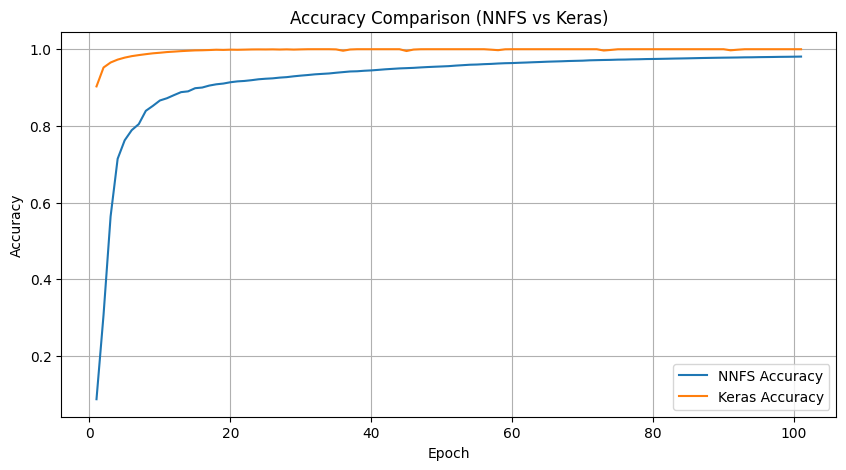

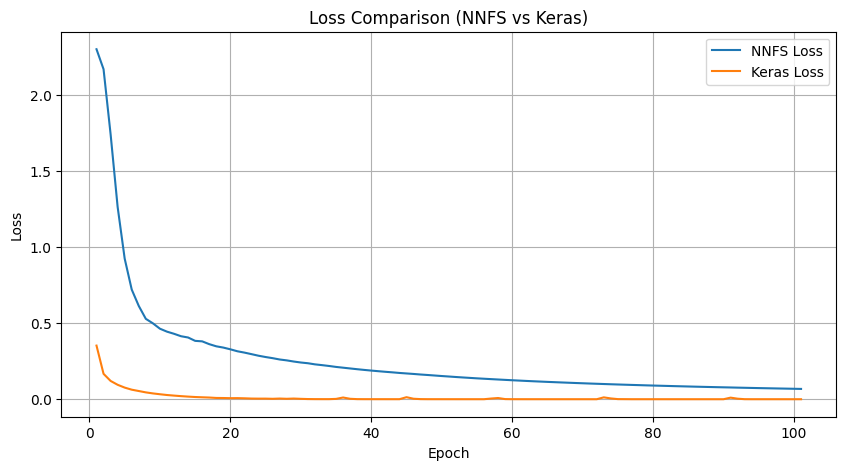

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, len(nnfs_acc_history) + 1)

# ======================
# ACCURACY COMPARISON
# ======================
plt.figure(figsize=(10,5))
plt.plot(epochs, nnfs_acc_history, label='NNFS Accuracy')
plt.plot(epochs, keras_acc[:len(epochs)], label='Keras Accuracy')

plt.title('Accuracy Comparison (NNFS vs Keras)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()


# ======================
# LOSS COMPARISON
# ======================
plt.figure(figsize=(10,5))
plt.plot(epochs, nnfs_loss_history, label='NNFS Loss')
plt.plot(epochs, keras_loss[:len(epochs)], label='Keras Loss')

plt.title('Loss Comparison (NNFS vs Keras)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()